In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

%matplotlib inline
pd.set_option('display.max_columns', None)

In [2]:
data = pd.read_csv(r"archive\dataset.csv")

In [23]:
df = data.copy()

In [24]:
df.head()

,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,1,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,1,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,0,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,0,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,2,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 114000 entries, 0 to 113999
Data columns (total 21 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0        114000 non-null  int64  
 1   track_id          114000 non-null  object 
 2   artists           113999 non-null  object 
 3   album_name        113999 non-null  object 
 4   track_name        113999 non-null  object 
 5   popularity        114000 non-null  int64  
 6   duration_ms       114000 non-null  int64  
 7   explicit          114000 non-null  bool   
 8   danceability      114000 non-null  float64
 9   energy            114000 non-null  float64
 10  key               114000 non-null  int64  
 11  loudness          114000 non-null  float64
 12  mode              114000 non-null  int64  
 13  speechiness       114000 non-null  float64
 14  acousticness      114000 non-null  float64
 15  instrumentalness  114000 non-null  float64
 16  liveness          11

In [26]:
df.shape

(114000, 21)

******

DATA CLEANING

In [ ]:
df_clean = df.drop(columns=["Unnamed: 0"])
df_clean.duplicated().sum()

np.int64(450)

In [41]:
df_clean = df_clean.drop_duplicates().reset_index()
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 113550 entries, 0 to 113549
Data columns (total 21 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   index             113550 non-null  int64  
 1   track_id          113550 non-null  object 
 2   artists           113549 non-null  object 
 3   album_name        113549 non-null  object 
 4   track_name        113549 non-null  object 
 5   popularity        113550 non-null  int64  
 6   duration_ms       113550 non-null  int64  
 7   explicit          113550 non-null  bool   
 8   danceability      113550 non-null  float64
 9   energy            113550 non-null  float64
 10  key               113550 non-null  int64  
 11  loudness          113550 non-null  float64
 12  mode              113550 non-null  int64  
 13  speechiness       113550 non-null  float64
 14  acousticness      113550 non-null  float64
 15  instrumentalness  113550 non-null  float64
 16  liveness          11

In [39]:
missing = df_clean.isna().sum().sort_values(ascending=False)
missing = missing[missing>0]
missing

album_name    1
track_name    1
artists       1
dtype: int64

In [126]:
df_clean.dropna()

,index,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre,loveintrack,youintrack
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,1,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.7150,87.917,4,acoustic,False,False
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,1,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.2670,77.489,4,acoustic,False,False
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,0,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.1200,76.332,4,acoustic,False,False
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,0,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.1430,181.740,3,acoustic,True,False
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,2,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.1670,119.949,4,acoustic,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
113545,113995,2C3TZjDRiAzdyViavDJ217,Rainy Lullaby,#mindfulness - Soft Rain for Mindful Meditatio...,Sleep My Little Boy,21,384999,False,0.172,0.2350,5,-16.393,1,0.0422,0.6400,0.928000,0.0863,0.0339,125.995,5,world-music,False,False
113546,113996,1hIz5L4IB9hN3WRYPOCGPw,Rainy Lullaby,#mindfulness - Soft Rain for Mindful Meditatio...,Water Into Light,22,385000,False,0.174,0.1170,0,-18.318,0,0.0401,0.9940,0.976000,0.1050,0.0350,85.239,4,world-music,False,False
113547,113997,6x8ZfSoqDjuNa5SVP5QjvX,Cesária Evora,Best Of,Miss Perfumado,22,271466,False,0.629,0.3290,0,-10.895,0,0.0420,0.8670,0.000000,0.0839,0.7430,132.378,4,world-music,False,False
113548,113998,2e6sXL2bYv4bSz6VTdnfLs,Michael W. Smith,Change Your World,Friends,41,283893,False,0.587,0.5060,7,-10.889,1,0.0297,0.3810,0.000000,0.2700,0.4130,135.960,4,world-music,False,False


In [127]:
df_clean.to_csv("cleaned_data.csv", index=False)

NUMERICAL AND CATEGORICAL VARIABLES

In [42]:
num = df_clean.select_dtypes(include="number")
cat = df_clean.select_dtypes(exclude="number")

In [35]:
num.head()

,popularity,duration_ms,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
0,73,230666,0.676,0.4610,1,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4
1,55,149610,0.420,0.1660,1,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4
2,57,210826,0.438,0.3590,0,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4
3,71,201933,0.266,0.0596,0,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3
4,82,198853,0.618,0.4430,2,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4


In [37]:
cat.head()

,track_id,artists,album_name,track_name,explicit,track_genre
0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,False,acoustic
1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,False,acoustic
2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,False,acoustic
3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,False,acoustic
4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,False,acoustic


******

EDA

Univariate analysis: VALENCE

valence: A measure from 0.0 to 1.0 describing the musical positiveness conveyed by a track. Tracks with high valence sound more positive (e.g. happy, cheerful, euphoric), while tracks with low valence sound more negative (e.g. sad, depressed, angry)


Numerical Variables:
- Measures of centrality: Mean, median
- Measures of dispersion: Variance,  standard deviation, minimum, maximum, range, quantiles
- Shape of the distribution: Symmetry and kurtosis
- Visualizations: Histograms, box plots


In [58]:
round(num["valence"].describe(),3)

count    113550.000
mean          0.474
std           0.259
min           0.000
25%           0.260
50%           0.464
75%           0.683
max           0.995
Name: valence, dtype: float64

VALENCE

- Median is slightly lower than the mean, suggesting skew in the distribution of VALENCE towards higher values (positiveness).
- The standard deviation:0.259. std/mean > 50% values can vary significantly from the average
- max: 0.995 and min: 0. almost the range of this variable.
- the IQR = Q3 - Q1. between 0.260 and 0.683, 50% of the values are between them.




In [154]:
valence = num["valence"]
print(f"std:",round(valence.std(),3))

std: 0.259


In [153]:
print(f"var:",round(valence.var(),3))

var: 0.067


In [152]:
print(f"skewness:",round(float(valence.skew()),3))

skewness: 0.115


skewness >0, distribution is positively skewed (right-skewed). long tail on the right side, the bulk of the data is concentrated on the left.

Histogram

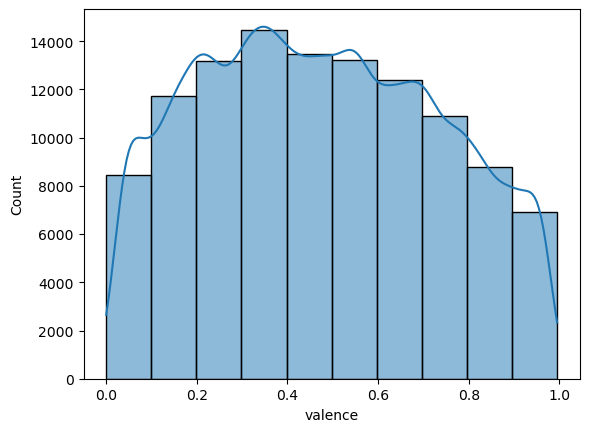

In [156]:
sns.histplot(valence, bins=10,kde=True)
plt.show()

In [158]:
print(f"kurtosis:", round(float(valence.kurt()),3))

kurtosis: -1.027


tail on the right side, confirming our earlier inference from the skewness value.
negative kurtosis, the tails are not heavy and there is significant dispersion, the values are not concentrated near the mean.

BOXplot

C:\Users\yoanl\AppData\Local\Temp\ipykernel_3044\3019182502.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(y=valence, palette="Set2")


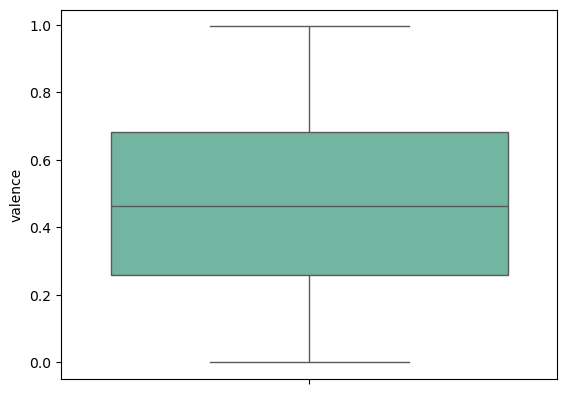

In [72]:
sns.boxplot(y=valence, palette="Set2")
plt.show()

no outliers, values are between 0 and 1

******

BIVARIATE ANALYSIS


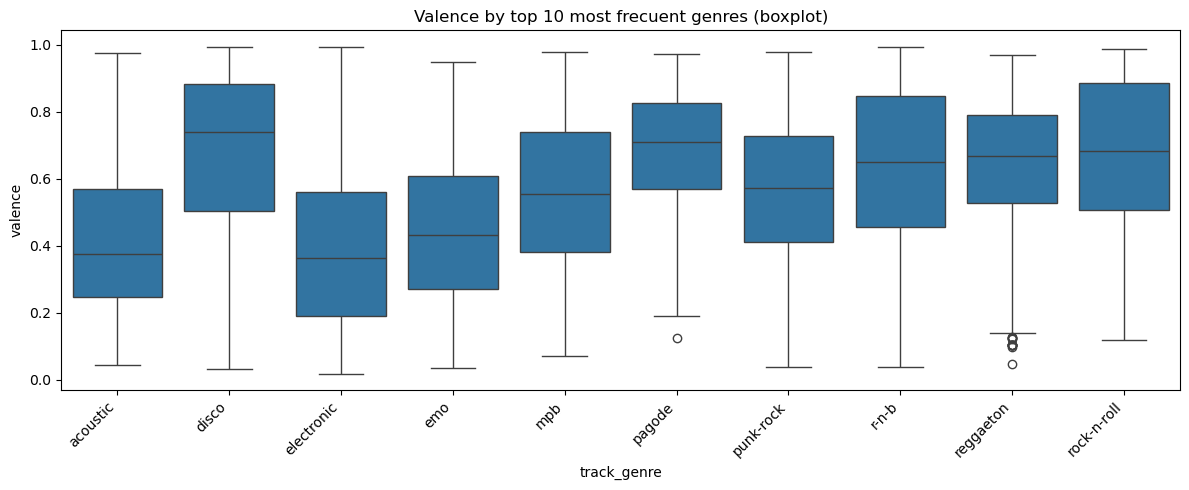

In [159]:
# Genre comparisons (top 10 by count)
top_genres = df_clean["track_genre"].value_counts().head(10).index
df_top = df_clean[df_clean["track_genre"].isin(top_genres)].copy()

plt.figure(figsize=(12,5))
sns.boxplot(data=df_top, x="track_genre", y="valence")
plt.xticks(rotation=45, ha="right")
plt.title("Valence by top 10 most frecuent genres (boxplot)")
plt.tight_layout()
plt.show()

reggaeton boxplots: outliers near value 0. it means that the valence values of this genre are concentrated near 0.6 and 0.8. majority positiveness.

pagode, needed to search about it. its brasilian music, subgenre of samba. same analysis as reggaeton.

acoustic, electronic and emo: less positive. 

In [146]:
round(df_clean[["track_genre","valence"]].groupby(by="track_genre").mean().sort_values(by="valence",ascending=False).head(5),3)

,valence
track_genre,
salsa,0.815
forro,0.760
rockabilly,0.727
afrobeat,0.698
ska,0.697


In [147]:
round(df_clean[["track_genre","valence"]].groupby(by="track_genre").mean().sort_values(by="valence",ascending=True).head(5),3)

,valence
track_genre,
sleep,0.058
iranian,0.153
ambient,0.167
new-age,0.183
black-metal,0.192


searched, most commom words in track names :love and you.

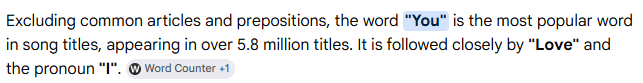

create new column with name loveintrack. boolean column.


In [161]:
df_clean["loveintrack"] = df_clean["track_name"].str.contains("love", case=False, na=False)
target_columns = ["index","track_name","loveintrack","valence"]
df_clean[target_columns].head()

,index,track_name,loveintrack,valence
0,0,Comedy,False,0.715
1,1,Ghost - Acoustic,False,0.267
2,2,To Begin Again,False,0.120
3,3,Can't Help Falling In Love,True,0.143
4,4,Hold On,False,0.167


1) its associate necessarily with any genre? CAT vs CAT

if the answer is yes, maybe can be a hint for the valence vs trackname analysis.
in general people associate the word love with good feelings, possitiveness, romance.

2) CAT vs CONT.
 H0: valance has no association with tracks that contains “love”.
H1: valance has positive association with tracks contains "love".


In [143]:
df_clean[["track_genre","loveintrack"]].groupby(by="track_genre").sum().sort_values(by="loveintrack",ascending=False).head(5)

,loveintrack
track_genre,
edm,90
chicago-house,74
synth-pop,69
dance,63
house,62


In [ ]:
crosstab_result = pd.crosstab(df_clean.loveintrack, df_clean.track_genre)
crosstab_result

track_genre,acoustic,afrobeat,alt-rock,alternative,ambient,anime,black-metal,bluegrass,blues,brazil,breakbeat,british,cantopop,chicago-house,children,chill,classical,club,comedy,country,dance,dancehall,death-metal,deep-house,detroit-techno,disco,disney,drum-and-bass,dub,dubstep,edm,electro,electronic,emo,folk,forro,french,funk,garage,german,gospel,goth,grindcore,groove,grunge,guitar,happy,hard-rock,hardcore,hardstyle,heavy-metal,hip-hop,honky-tonk,house,idm,indian,indie,indie-pop,industrial,iranian,j-dance,j-idol,j-pop,j-rock,jazz,k-pop,kids,latin,latino,malay,mandopop,metal,metalcore,minimal-techno,mpb,new-age,opera,pagode,party,piano,pop,pop-film,power-pop,progressive-house,psych-rock,punk,punk-rock,r-n-b,reggae,reggaeton,rock,rock-n-roll,rockabilly,romance,sad,salsa,samba,sertanejo,show-tunes,singer-songwriter,ska,sleep,songwriter,soul,spanish,study,swedish,synth-pop,tango,techno,trance,trip-hop,turkish,world-music
loveintrack,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
True,61,12,10,15,16,10,4,21,49,2,23,59,13,74,13,49,2,24,14,32,63,38,5,55,36,58,29,25,37,36,90,58,36,18,20,2,18,28,33,17,1,12,6,36,12,18,25,32,8,19,1,35,52,62,21,19,42,42,19,5,23,22,24,24,29,35,17,2,2,3,10,14,6,15,4,28,27,4,2,42,50,7,40,50,33,16,19,15,6,0,14,40,57,4,45,0,2,0,23,31,3,3,31,57,2,9,36,69,0,12,27,27,2,50
False,939,987,989,984,983,989,993,977,949,996,976,941,986,924,985,950,931,971,982,968,902,961,994,943,962,942,970,971,962,963,903,940,964,982,979,996,981,972,967,946,998,987,992,962,987,981,974,966,991,979,997,956,929,937,977,980,955,958,981,983,970,977,974,976,970,964,974,988,991,996,990,984,994,983,996,966,965,996,992,956,943,992,956,949,963,983,981,985,994,1000,986,960,942,900,955,998,998,1000,976,969,997,997,969,942,998,989,964,931,1000,988,972,970,997,949


acoustic 61 tracks that contain "love".

blues 49, british 59, chicago house 74, edm 90 i think is max.
reggaeton salsa, tango 0. because their names are in spanish.

striking .
romance only 4 and sad songs 45, so not neccesarely associate word love with any genre.


CAT vs CONT


BOX PLOT

C:\Users\yoanl\AppData\Local\Temp\ipykernel_3044\1020874076.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean, x="loveintrack", y="valence", palette="coolwarm", legend=True)


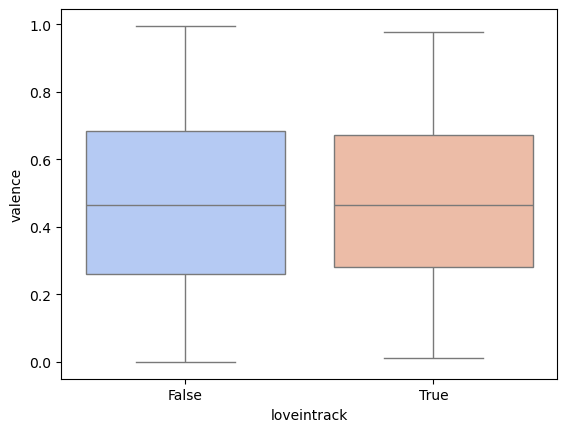

In [108]:
sns.boxplot(data=df_clean, x="loveintrack", y="valence", palette="coolwarm", legend=True)
plt.show()

same median, iqr smaller in tracks with "love". cant tell the diference

C:\Users\yoanl\AppData\Local\Temp\ipykernel_3044\3737297081.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_clean, x="loveintrack", y="valence", palette="coolwarm")


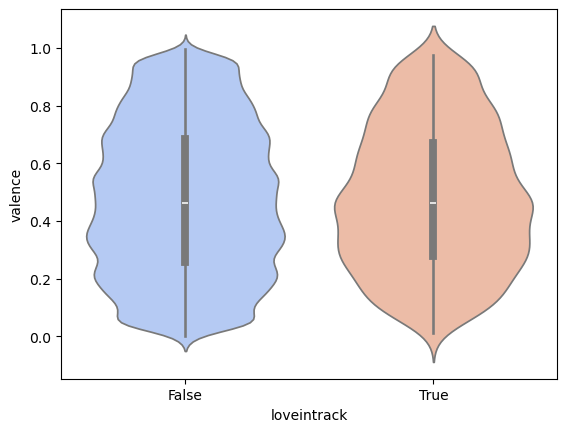

In [109]:
sns.violinplot(data=df_clean, x="loveintrack", y="valence", palette="coolwarm")
plt.show()

with violin plot we can identify that surprisingly the values of valence near 1( higher, postive) are less dense in kernel density , thinner on top, than the values near 0. 
a clue that the association love with happines in songs are the oposite. maybe, they are linked to sad songs.

analysis with word "you"

In [111]:
df_clean["youintrack"] = df_clean["track_name"].str.contains("you", case=False, na=False)
df_clean

,index,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre,loveintrack,youintrack
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,1,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.7150,87.917,4,acoustic,False,False
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,1,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.2670,77.489,4,acoustic,False,False
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,0,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.1200,76.332,4,acoustic,False,False
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,0,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.1430,181.740,3,acoustic,True,False
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,2,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.1670,119.949,4,acoustic,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
113545,113995,2C3TZjDRiAzdyViavDJ217,Rainy Lullaby,#mindfulness - Soft Rain for Mindful Meditatio...,Sleep My Little Boy,21,384999,False,0.172,0.2350,5,-16.393,1,0.0422,0.6400,0.928000,0.0863,0.0339,125.995,5,world-music,False,False
113546,113996,1hIz5L4IB9hN3WRYPOCGPw,Rainy Lullaby,#mindfulness - Soft Rain for Mindful Meditatio...,Water Into Light,22,385000,False,0.174,0.1170,0,-18.318,0,0.0401,0.9940,0.976000,0.1050,0.0350,85.239,4,world-music,False,False
113547,113997,6x8ZfSoqDjuNa5SVP5QjvX,Cesária Evora,Best Of,Miss Perfumado,22,271466,False,0.629,0.3290,0,-10.895,0,0.0420,0.8670,0.000000,0.0839,0.7430,132.378,4,world-music,False,False
113548,113998,2e6sXL2bYv4bSz6VTdnfLs,Michael W. Smith,Change Your World,Friends,41,283893,False,0.587,0.5060,7,-10.889,1,0.0297,0.3810,0.000000,0.2700,0.4130,135.960,4,world-music,False,False


In [112]:
crosstab_result = pd.crosstab(df_clean.youintrack, df_clean.track_genre)
crosstab_result

track_genre,acoustic,afrobeat,alt-rock,alternative,ambient,anime,black-metal,bluegrass,blues,brazil,breakbeat,british,cantopop,chicago-house,children,chill,classical,club,comedy,country,dance,dancehall,death-metal,deep-house,detroit-techno,disco,disney,drum-and-bass,dub,dubstep,edm,electro,electronic,emo,folk,forro,french,funk,garage,german,gospel,goth,grindcore,groove,grunge,guitar,happy,hard-rock,hardcore,hardstyle,heavy-metal,hip-hop,honky-tonk,house,idm,indian,indie,indie-pop,industrial,iranian,j-dance,j-idol,j-pop,j-rock,jazz,k-pop,kids,latin,latino,malay,mandopop,metal,metalcore,minimal-techno,mpb,new-age,opera,pagode,party,piano,pop,pop-film,power-pop,progressive-house,psych-rock,punk,punk-rock,r-n-b,reggae,reggaeton,rock,rock-n-roll,rockabilly,romance,sad,salsa,samba,sertanejo,show-tunes,singer-songwriter,ska,sleep,songwriter,soul,spanish,study,swedish,synth-pop,tango,techno,trance,trip-hop,turkish,world-music
youintrack,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
False,856,970,947,931,950,972,982,940,924,993,951,890,985,885,947,890,928,926,947,874,858,955,967,900,954,914,923,926,937,928,874,873,952,941,935,997,960,954,900,925,991,974,979,946,920,963,930,927,966,957,996,967,827,886,970,986,937,925,944,960,943,989,955,971,908,972,916,980,989,995,977,915,930,971,996,960,956,998,987,896,934,991,899,880,919,948,961,974,995,998,893,949,911,898,880,995,999,1000,916,902,983,995,902,873,997,976,938,912,1000,956,954,954,996,875
True,144,29,52,68,49,27,15,58,74,5,48,110,14,113,51,109,5,69,49,126,107,44,32,98,44,86,76,70,62,71,119,125,48,59,64,1,39,46,100,38,8,25,19,52,79,36,69,71,33,41,2,24,154,113,28,13,60,75,56,28,50,10,43,29,91,27,75,10,4,4,23,83,70,27,4,34,36,2,7,102,59,8,97,119,77,51,39,26,5,2,107,51,88,6,120,3,1,0,83,98,17,5,98,126,3,22,62,88,0,44,45,43,3,124


In [114]:
df_clean.youintrack.value_counts()

youintrack
False    107569
True       5981
Name: count, dtype: int64

C:\Users\yoanl\AppData\Local\Temp\ipykernel_3044\219179246.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean, x="youintrack", y="valence", palette="coolwarm", legend=True)


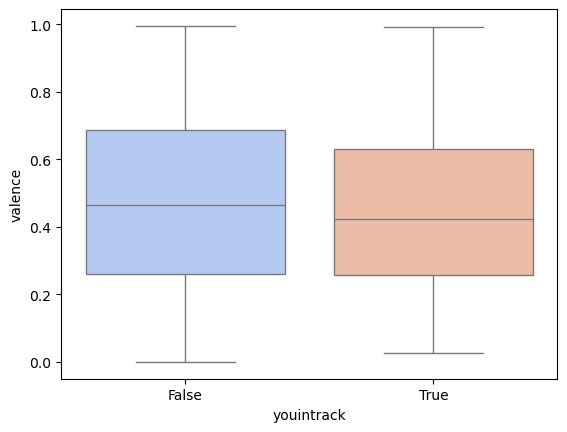

In [115]:
sns.boxplot(data=df_clean, x="youintrack", y="valence", palette="coolwarm", legend=True)
plt.show()

C:\Users\yoanl\AppData\Local\Temp\ipykernel_3044\217420336.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_clean, x="youintrack", y="valence", palette="coolwarm")


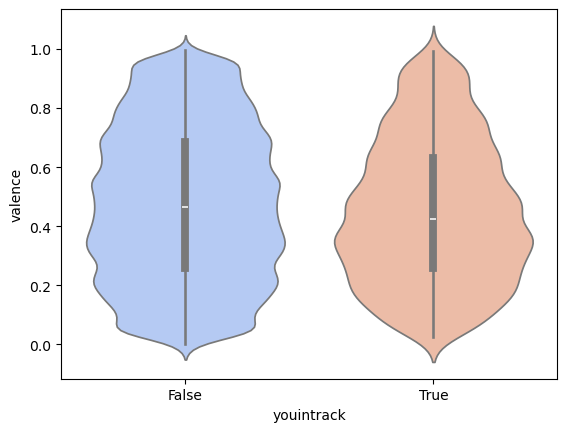

In [116]:
sns.violinplot(data=df_clean, x="youintrack", y="valence", palette="coolwarm")
plt.show()

back to analyse univariate valence only with loveintrack

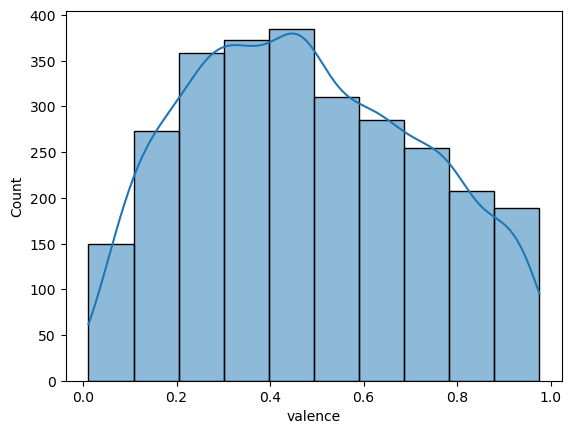

In [125]:
df_clean_love = df_clean[df_clean["loveintrack"] == True]

valence_love = df_clean_love["valence"]
sns.histplot(valence_love, bins=10,kde=True)
plt.show()


histogram: clearly concentrated in left side, positive skewness, tail on right side.


H0: valance has no association with tracks that contains “love”.
H1: valance has positive association with tracks contains "love".
H2: valance has negative association with tracks


Although the word “love” has a positive connotation, in songs it can mean the exact opposite. Based on this analysis, we conclude that songs containing the word “love” do not necessarily imply something positive. Furthermore, we add that it has a more negative than positive meaning.

business question for SQL: does the word "love" in track_name has a positive connotation?